In [1]:
#import libraries 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3 

# 1 Import data / database 

In [2]:
df_customer = pd.read_csv("data/db_customer.csv")
df_subscription = pd.read_csv("data/db_subscription.csv")
df_support = pd.read_csv("data/db_support.csv")

# 2 Data Cleaning 

In [3]:
df_customer.head()
df_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,NaN
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,NaN
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,NaN
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,NaN
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,NaN


In [4]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  21 non-null     object 
 1   name        21 non-null     object 
 2   country     18 non-null     object 
 3   state       21 non-null     object 
 4   gender      21 non-null     object 
 5   dob         21 non-null     object 
 6   interests   4 non-null      object 
 7   pincode     0 non-null      float64
dtypes: float64(1), object(7)
memory usage: 1.4+ KB


In [5]:
# a. rename column - name 
# b. drop column - intrest and pincode 
# c. change data type - dob
# d. data standarization - gender 
# e. fix missing values - country 

In [6]:
# a. rename column - name 

df_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)
df_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,NaN
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,NaN
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,NaN
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,NaN
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,NaN
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,NaN


In [7]:
# b. drop column - intrest and pincode

df_customer.drop(df_customer.columns[-2:], axis = 1 , inplace=True )


In [8]:
# c. change data type - dob 

df_customer['dob'] = pd.to_datetime(df_customer['dob'])

In [9]:
# d. data standarization - gender 

df_customer['gender'].unique()

df_customer['gender'] = df_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [10]:
# e. fix missing values - country 

df_customer[df_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [11]:
# country and state - unique value pair 

state_country_mapping = df_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_customer['country'] = df_customer['country'].fillna(df_customer['state'].map(state_country_mapping))

In [12]:
df_subscription.head()
df_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaN,NaN,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaN,NaN,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaN,NaN,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaN,NaN,13.99,790,47


In [13]:
df_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [14]:
date_col = ['subscription_start_date' , 'renewal_date' , 'cancellation_date']

df_subscription[date_col] = df_subscription[date_col].apply(pd.to_datetime)

In [15]:
df_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,NaN,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,NaN,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,NaN,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,NaN,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,NaN,NaN


In [16]:
df_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerid      9 non-null      object 
 1   complaint_date  9 non-null      object 
 2   escalations     9 non-null      object 
 3   csat_score      9 non-null      int64  
 4   col_1           0 non-null      float64
 5   comment         4 non-null      object 
dtypes: float64(1), int64(1), object(4)
memory usage: 564.0+ bytes


In [17]:
df_support.drop(columns = ['col_1' , 'comment'] , inplace = True)

In [18]:
df_support['complaint_date'] = pd.to_datetime(df_support['complaint_date'])

# 3 Feature Engineering and Data Analysis 

In [19]:
# create a new column using existing column
df_subscription['churn_flag'] = np.where(df_subscription['cancellation_date'].notna(),1 , 0)

In [20]:
df_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0


In [21]:
 df_support['complaint_count'] = df_support.groupby('customerid')['customerid'].transform('count')

In [22]:
df_support.shape

(9, 5)

In [23]:
df_support = df_support.sort_values('complaint_date').drop_duplicates('customerid', keep ='last')

In [24]:
# first fix support table duplicates then merge
df = (df_subscription
    .merge(df_customer , on = 'customerid' , how = 'left')
    .merge(df_support , on = 'customerid' , how = 'left'))

In [25]:
df.shape

(21, 21)

In [26]:
df.to_csv("data/exported_churn_data.csv", index=False)

# 4 Data Analysis 

In [27]:
# 1 Churn Rate 

churn_rate = df["churn_flag"].mean()*100
print("Churn Rate = " , round(churn_rate,2),"%")

Churn Rate =  28.57 %


In [28]:
# 2 Retention Rate 

retention_rate = 100 - churn_rate
print("Retention Rate = " , round(retention_rate,2),"%")

Retention Rate =  71.43 %


In [29]:
df.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN


In [30]:
# 3 Churn by Plan type

churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_cpt'))
print(churn_by_plan)

  plan_type  churn_rate_cpt
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [31]:
#4 a. Churn rate by state + sum of revenue & count of users 

churn_by_state = (
    df.groupby("state")
      .agg(
          churn_rate_pct=("churn_flag", lambda x: x.mean() * 100),
          total_revenue=("monthly_charges", "sum"),
          user_count=("customerid", "count")
      )
      .round({"churn_rate_pct": 2, "total_revenue": 2})
      .reset_index()
)

print(churn_by_state)


           state  churn_rate_pct  total_revenue  user_count
0          Delhi           25.00          52.96           4
1      Karnataka          100.00          20.98           2
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
4      Meghalaya           66.67          42.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
7      Telangana           50.00          30.98           2
8  Uttar Pradesh            0.00         115.98           2


In [32]:
# b. Churn rate by ssubscription + sum of revenue & count of users 

churn_by_subscription = df.groupby('subscription_type').agg(
    churn_rate_cpt=('churn_flag', lambda x: round(x.mean() * 100, 2)),
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count')
).reset_index()

print(churn_by_subscription)

  subscription_type  churn_rate_cpt  total_revenue  user_count
0           Organic            0.00         145.91           9
1              Paid           16.67         174.94           6
2          Refferal           83.33          74.94           6


In [33]:
# 5 ARPU - Avg Revenue per User 

arpu = df['monthly_charges'].mean()
print("ARPU = ", round(arpu,2))

ARPU =  18.85


In [34]:
# 6 Avg Customer tenure 
# count of days user has used our service : cancellation date else current date 

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
     (today - df['subscription_start_date'] ).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (days) = ", round(avg_tenure),0)

Avg Tenure (days) =  1491 0


In [35]:
# 7 Revenue at risk - revenue lost from churned users 

revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("Revenue at risk  = " , revenue_at_risk,"k")

Revenue at risk  =  73.94 k


In [36]:
# 8 Esclation Rate

escalation_rate = (df['escalations'] =='Y').mean()*100
print("Escalation Rate = " , round(escalation_rate,2),"%")

Escalation Rate =  19.05 %


In [37]:
# 9 Avg Complaint Per User 

avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaints Per User = ", round(avg_complaints, 2))

Avg Complaints Per User =  0.43


In [38]:
# 10 Correlation Escalation VS Churn

df['escalations'] = np.where(df['escalations'] == 'Y' ,1,0) # encoding string to int type


corr_df = df[['customerid' , 'escalations' , 'churn_flag']].dropna()

# correlations

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escaltion vs churn is =" , round(correlation,2))

Correlation between escaltion vs churn is = 0.77


In [39]:
# 11 churn risk - create a column using existing col 

conditions = [
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70 )
]

choices = ['low ' , 'med' , 'high']

df['churn_risk'] = np.select(conditions , choices , default ='unknown')

## 4 Visualizations using matplotlib

In [40]:
df_visual = df.copy()

In [41]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

<function matplotlib.pyplot.show(close=None, block=None)>

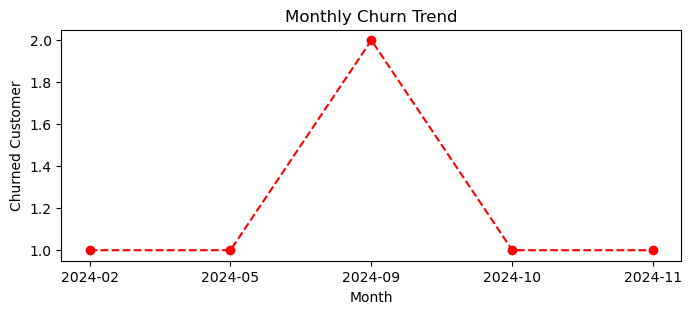

In [42]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize =(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color = "red", marker = "o" , linestyle ='dashed')
plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churned Customer")
plt.show

<BarContainer object of 3 artists>

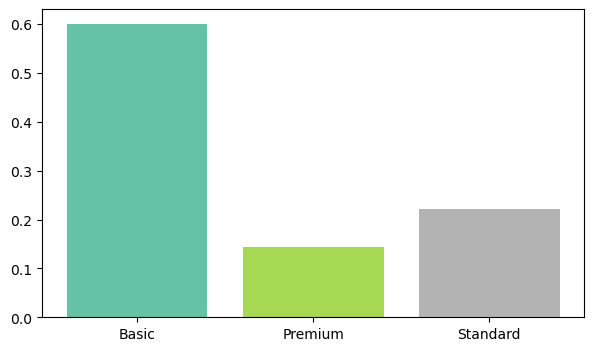

In [43]:
# 4.2 Churn by plan type 

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0,1 , len(churn_plan)))
plt.figure(figsize =(7,4))

plt.bar(churn_plan.index , churn_plan.values, color = colors )

<BarContainer object of 9 artists>

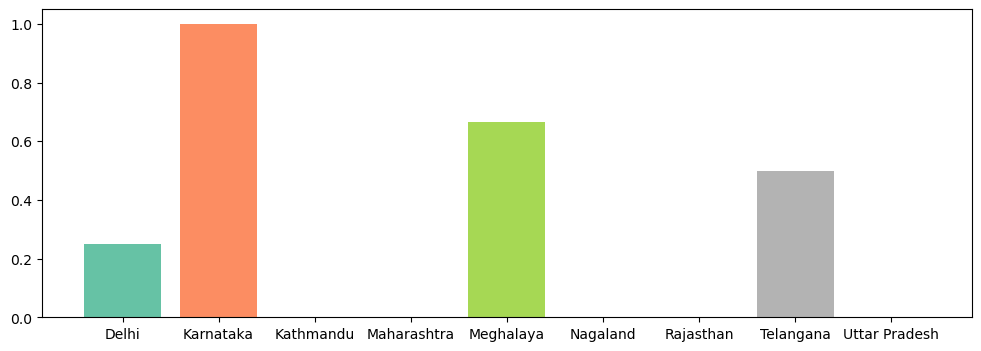

In [44]:
# 4.3 Churn by state

churn_plan = df_visual.groupby('state')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0,1 , len(churn_plan)))
plt.figure(figsize =(12,4))

plt.bar(churn_plan.index , churn_plan.values, color = colors )

# 5 Visualizations Using Seaborn 

In [45]:
# encoding - convert str to numeric values
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [46]:
import warnings 
warnings.filterwarnings('ignore')

In [47]:
# moethod of encoding - based on priority 

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score','churn_flag', 'escalations', 'churn_risk']]

order_mappings = {'plan_type' : ['Basic', 'Standard' ,'Premium'],
                  
                  'contract_type' : ['Monthly' , 'Annual'],
                  
                  'churn_risk' : ['low' , 'med' , 'high']}

for col,order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order , ordered=True).codes

In [48]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,-1
1,2,1,91,1,1,2
2,0,0,34,0,0,-1
3,2,1,8,0,0,-1
4,1,0,88,1,1,2


In [49]:
df_visual[['plan_type', 'contract_type', 'churn_score','churn_flag', 'escalations', 'churn_risk']].head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


<Axes: >

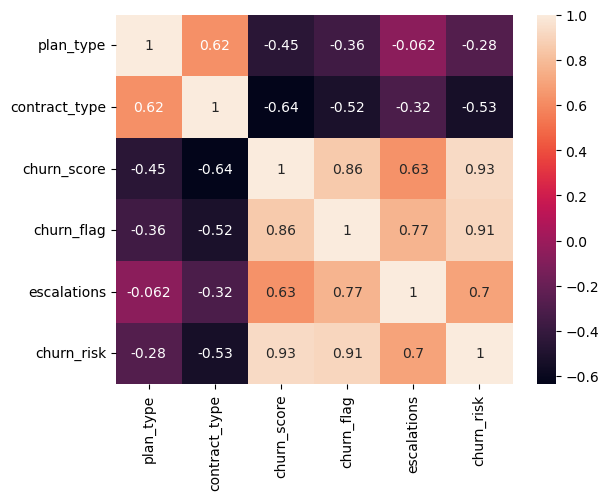

In [50]:
# heatmap (correlation matrix ) 

sns.heatmap(df_encoded.corr(), annot=True)

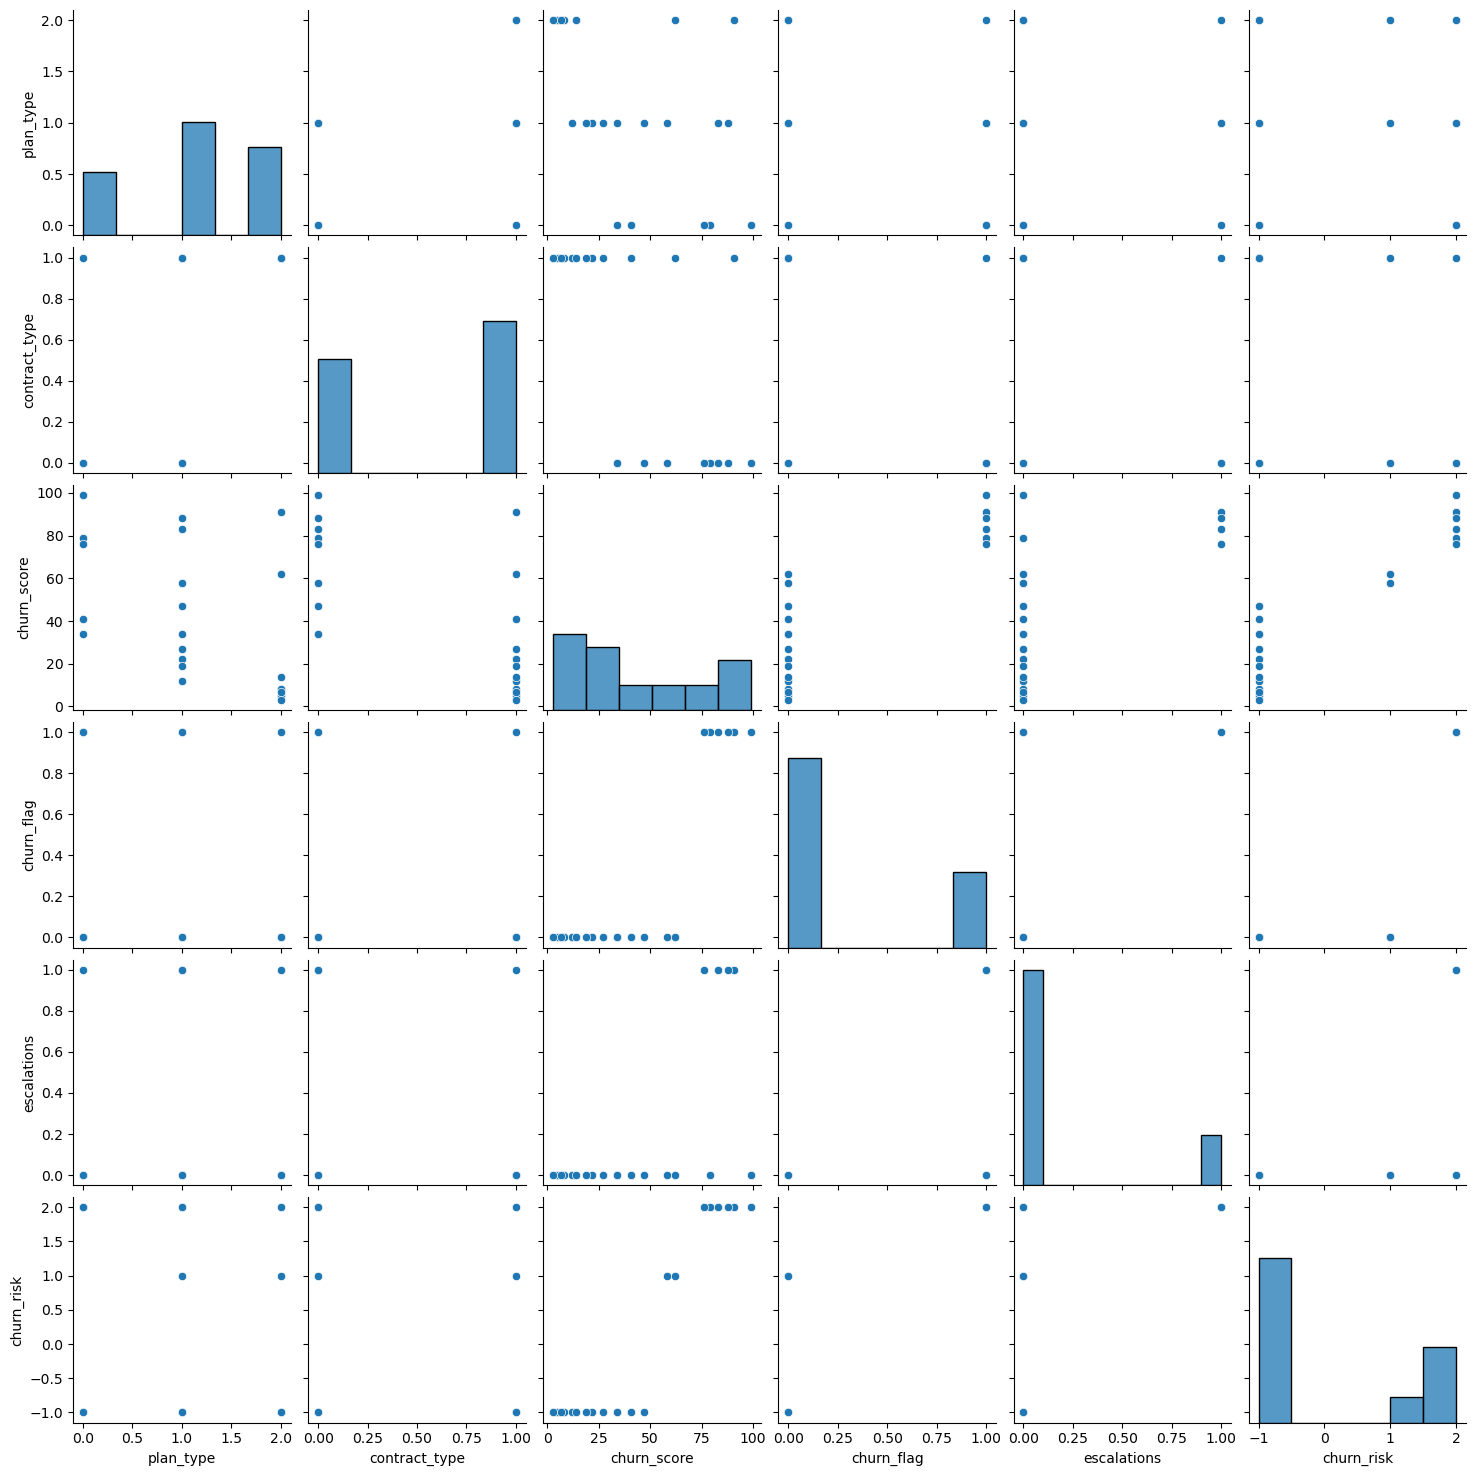

In [51]:
# pairplot 

sns.pairplot(df_encoded)

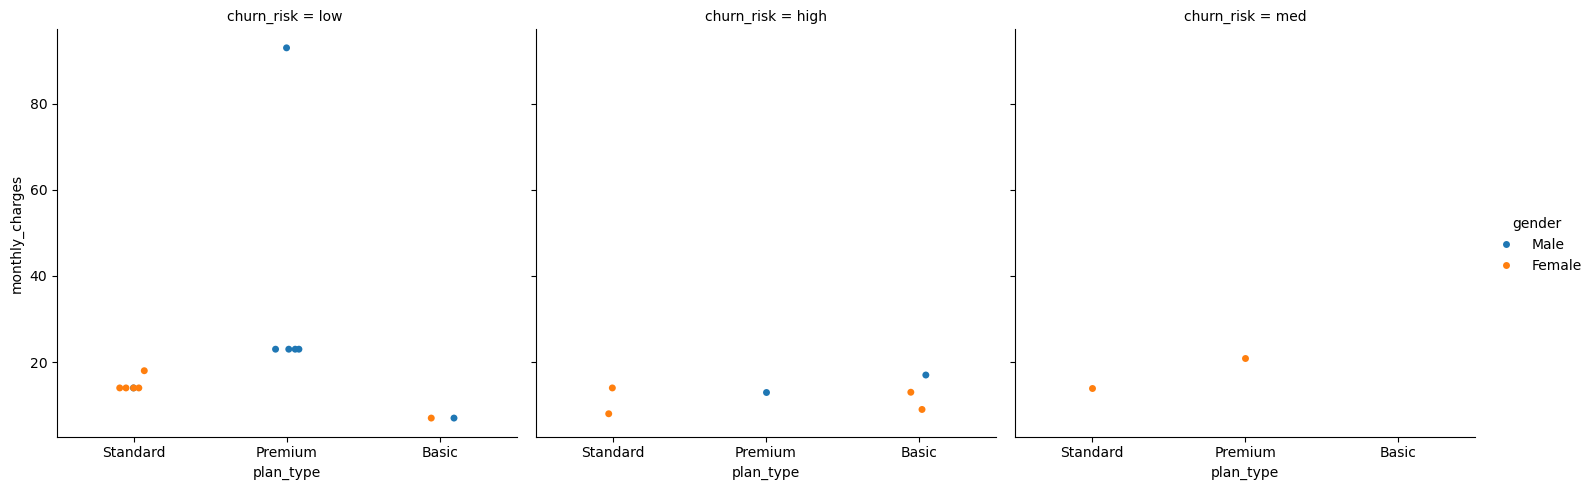

In [52]:
# catplot / facegrid - multi dimension comparision 

sns.catplot(data= df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')
    

In [53]:
# pivot tables 

pd.pivot_table(
    df_visual,
    values= 'churn_flag',
    index='plan_type',
    aggfunc ='mean'
              
              ).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [54]:
pd.pivot_table(
    df_visual,
    values= ['churn_flag', 'monthly_charges', 'customerid'],
    index='plan_type',
    aggfunc = {
        'churn_flag': 'mean' ,
        'monthly_charges': 'sum',
        'customerid': 'nunique'
    }
              
              )

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [55]:
# working with SQL in python (pandas)

In [56]:
# create database in sql 


conn = sqlite3.connect('test_database.sqlite')

# table details

conn.execute("CREATE TABLE users(first_name TEXT , country TEXT , budget INTEGER)")

OperationalError: table users already exists

In [ ]:
# Commit and save 

conn.commit()

In [ ]:
# insert data 
cursor = conn.cursor() 

cursor.execute("""
    INSERT INTO users VALUES 
    ('Utkarsh', 'india', 5000), 
    ('rishab', 'usa', 6000) 
""") 

conn.commit() 
print("data inserted successfully")

In [ ]:
# check inserted data in table 

conn = sqlite3.connect('test_database.sqlite')
query = """ SELECT * FROM users """

df_results = pd.read_sql(query , conn)

df_results

In [58]:
exported_churn_data.to_csv(
    "exported_churn_data.csv",
    index=False,
    encoding="utf-8"
)

NameError: name 'exported_churn_data' is not defined

In [59]:
import os

print(os.path.abspath("data/exported_churn_data.csv"))

C:\Users\USER\PROJECT\Churn Analysis\data\exported_churn_data.csv
